# 02 · Clustering a map into phases

*Group indents that behave alike (with no labels) and paint the result back onto the map.*

> ⏱ **Runtime:** ~30 s on a laptop CPU (no GPU) · 🎓 **Level:** beginner · 📊 **Data:** Al–Cu map

### 🎯 What you'll learn
1. what **clustering** is and why it is called *unsupervised*,
2. **k-means** and how to *choose k* with the **silhouette** (cross-checked by GMM's **BIC**),
3. **Gaussian Mixture Models** for soft labels and an **uncertainty** map,
4. **HDBSCAN** (no k, flags outliers) and how to check methods **agree** (ARI).

### 🧭 What you need to know first
- Notebook **01** (features, standardisation).
- That each Al–Cu indent has features `H`, `E`, `H/E`.

### Step 0: set-up

Run the setup cell first. In Jupyter, **Shift + Enter** runs whichever cell is selected.

> 🟢 **Running on Colab?** The cell also fetches the repo and a few extra packages, about a minute the first time. Locally it is instant once the requirements are installed.

> ✅ **You should see:** a line like `helpers loaded from: .../mecanano_ml/__init__.py`. That confirms the helper package loaded correctly.

In [1]:
# --- Setup cell — run me first! ---------------------------------------------
# It makes the helper package `mecanano_ml` importable and sets a clean plot
# style. You do not need to understand every line here; just run it.
# On Google Colab it also clones the repo and installs the few extra packages
# Colab doesn't ship (takes ~1 min, once per session).
import os, sys, subprocess

def _find_src():
    # Look for the repo's src/ folder in the usual places (local clone / Colab).
    for p in ("../src", "src", "mecanano-ml-nanomechanics/src"):
        if os.path.isdir(p):
            return p
    return None

if "google.colab" in sys.modules:             # running on Colab -> set everything up
    # packages Colab does not preinstall (torch/sklearn/etc. are already there):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "hdbscan", "umap-learn", "pyts", "shap", "imbalanced-learn"],
                   check=False)

if _find_src() is None:                       # bare session (e.g. Colab): fetch the repo
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/edrossi93/mecanano-ml-nanomechanics.git"],
                   check=False)

sys.path.insert(0, os.path.abspath(_find_src() or "mecanano-ml-nanomechanics/src"))

import numpy as np                 # arrays and maths
import pandas as pd                # tables (each row = one indent)
import matplotlib.pyplot as plt    # plotting
import mecanano_ml as mm           # our tiny helper package: loaders + plotting
mm.set_style()                     # consistent, publication-like figures
# Confirm the helpers loaded (just the tail of the path, not your machine's folders).
_pkg = os.path.basename(os.path.dirname(mm.__file__))
print("helpers loaded from: .../" + _pkg + "/" + os.path.basename(mm.__file__))

helpers loaded from: .../mecanano_ml/__init__.py


> 🧠 **clustering**: grouping samples so that members of a group are more alike than members of different groups (here, sorting indents into phases).

> 🧠 **unsupervised**: learning from the data alone, with **no answer key** (no labels). We never tell the algorithm which indent is which phase; it discovers the grouping itself.

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
rng = np.random.default_rng(0)          # a fixed random seed -> reproducible results

## 1 · Features

Same three standardised features as notebook 01 (`H`, `E`, `H/E`), for the full Al–Cu map.

> ✅ **What to look for:** the number of indents (~40,000). Each is now a standardised 3-feature vector.

In [3]:
df = mm.load_map("alcu_2um")
# Standardise so no feature dominates just because of its units (GPa vs ratio).
Xs = StandardScaler().fit_transform(df[["H", "E", "HE"]].values)
print("indents:", Xs.shape[0])

indents: 40000


## 2 · How many phases?

**k-means** splits the data into `k` groups, but you must tell it `k` in advance. To *choose*
`k` we score each option with the **silhouette**, then cross-check with a Gaussian mixture's **BIC**.

> 🧠 **k-means**: a clustering method that places `k` centres and assigns each point to its nearest centre, then nudges the centres until they settle. Fast and simple, but you pick `k`.

> 🧠 **silhouette score**: for each point, how much closer it is to its own cluster than to the next-nearest one, averaged over all points. Ranges −1…1; higher is better. The `k` with the highest silhouette is a good choice.

> ℹ️ The silhouette compares every point to every other, so it costs O(n²). The clustering
> itself uses **all 40,000** indents; only this score is evaluated on a random 10,000-point
> sample to keep it fast. The score barely changes.

> ✅ **What to look for:** a curve of silhouette vs k with a dashed line at the best k (expected **k = 2** ≈ 0.6, matching the two phases).

silhouettes: [0.615 0.482 0.438 0.41  0.398]


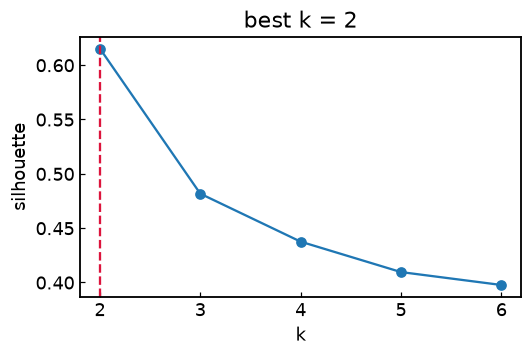

In [4]:
ks = range(2, 7)                        # try k = 2, 3, 4, 5, 6
sil = []
for k in ks:
    lab = KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(Xs)
    # KMeans above clusters all 40,000 points; only this O(n^2) score samples (10,000) to stay fast.
    sil.append(silhouette_score(Xs, lab, sample_size=10000, random_state=0))
best_k = list(ks)[int(np.argmax(sil))]  # k with the highest silhouette

fig, ax = plt.subplots(figsize=(5, 3.4))
ax.plot(list(ks), sil, "o-"); ax.axvline(best_k, ls="--", c="crimson")
ax.set_xlabel("k"); ax.set_ylabel("silhouette"); ax.set_title(f"best k = {best_k}")
fig.tight_layout(); print("silhouettes:", np.round(sil, 3))

*🖼 **Figure.** The silhouette peaks at k = 2, so the data most naturally splits into two groups, exactly the two phases we saw in the histogram in notebook 00.*

### A second opinion on *k*: GMM's BIC

The silhouette is one way to choose `k`. A **Gaussian mixture** gives another: fit it for a range
of `k` and compare the **BIC**. It is worth doing because the two criteria can disagree — and here
the disagreement is the interesting part.

> 🧠 **BIC (Bayesian Information Criterion)**: a model-selection score, lower is better. It rewards fit but charges for every extra component, so it will not add complexity for free.

> ✅ **What to look for:** BIC falling fast to k = 2–3 then levelling off, and a printed 3-component fit whose *middle* mode has an intermediate hardness — the interface population.

BIC  k=1..6 : ['178,591', '148,111', '139,086', '137,427', '136,783', '136,600']
gain k->k+1 : ['30,480', '9,025', '1,659', '643', '183']



3-component GMM, sorted by hardness:
  weight 0.21   H 1.4 GPa   E 74 GPa
  weight 0.16   H 3.8 GPa   E 86 GPa
  weight 0.64   H 4.9 GPa   E 94 GPa


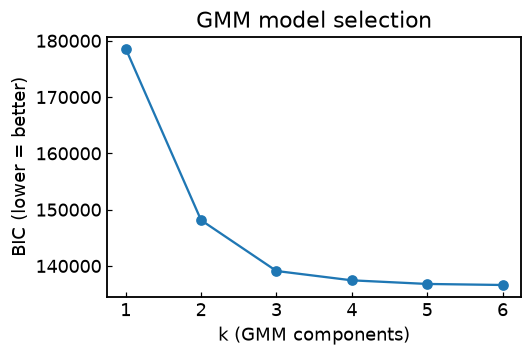

In [5]:
# Let GMM weigh in. Score k = 1..6 by BIC on the two physical properties H, E
# (the H/E ratio we added for k-means is derived; here we let GMM see the physics directly).
sc_he = StandardScaler().fit(df[["H", "E"]].values)
Xhe = sc_he.transform(df[["H", "E"]].values)
bic = [GaussianMixture(k, covariance_type="full", random_state=0).fit(Xhe).bic(Xhe) for k in range(1, 7)]
print("BIC  k=1..6 :", [f"{b:,.0f}" for b in bic])
print("gain k->k+1 :", [f"{bic[i] - bic[i + 1]:,.0f}" for i in range(len(bic) - 1)])

fig, ax = plt.subplots(figsize=(5, 3.4))
ax.plot(range(1, 7), bic, "o-"); ax.set_xlabel("k (GMM components)"); ax.set_ylabel("BIC (lower = better)")
ax.set_title("GMM model selection"); fig.tight_layout()

# The 3rd component is not noise: its mean sits BETWEEN the two phases (interface / mixed indents).
g3 = GaussianMixture(3, covariance_type="full", random_state=0).fit(Xhe)
m3 = sc_he.inverse_transform(g3.means_)
print("\n3-component GMM, sorted by hardness:")
for i in np.argsort(m3[:, 0]):
    print(f"  weight {g3.weights_[i]:.2f}   H {m3[i, 0]:.1f} GPa   E {m3[i, 1]:.0f} GPa")

*🖼 **Figure.** BIC drops steeply to k = 2, still improves clearly at k = 3, then flattens — so the honest range is **2–3**, not more. (On ~40,000 points the raw BIC keeps inching down, so read the elbow, not the strict minimum.) The third component is not noise: its mean sits **between** the two phases (H ≈ 3.8 GPa, versus ≈ 1.4 for the soft matrix and ≈ 4.9 for the hard intermetallic) — the **interface / mixed** indents that sample both phases. So **k = 2 is the clean structural answer** (matching the silhouette and HDBSCAN), while **k = 3 is a defensible finer view**. We keep k = 2 for the phase maps below.*

## 3 · k-means phase map

Fit at the chosen `k`, then paint each indent's cluster label back onto its (x, y)
position. Coherent regions = real phases (not random speckle).

> ✅ **What to look for:** two panels: a **phase map** with two clean regions, and the same clusters shown in feature space (H vs E).

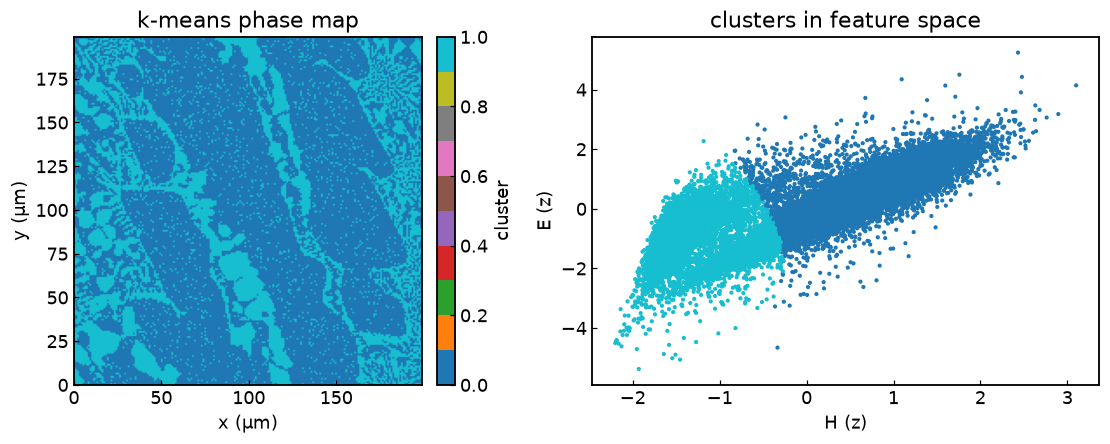

In [6]:
km = KMeans(n_clusters=best_k, n_init=10, random_state=0).fit(Xs)
df["cluster"] = km.labels_              # attach each indent's cluster id to the table
gmap, ext = mm.map_to_grid(df, "cluster")   # reshape labels into a 2-D image

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
mm.plot_map(gmap, ext, ax=ax[0], cmap="tab10", label="cluster", title="k-means phase map")
sc = ax[1].scatter(Xs[:, 0], Xs[:, 1], c=km.labels_, s=3, cmap="tab10")
ax[1].set_xlabel("H (z)"); ax[1].set_ylabel("E (z)"); ax[1].set_title("clusters in feature space")
fig.tight_layout()

*🖼 **Figure.** Left: the phase map, two spatially coherent regions, which is how you know the clustering found real microstructure. Right: the same split seen as two groups in feature space.*

## 4 · Soft labels and uncertainty (GMM)

k-means gives every indent one hard label. A **Gaussian Mixture Model** instead gives a
*probability* of belonging to each phase, so we can map **confidence**, and watch it drop
at phase **boundaries**, where an indent samples a mix of both phases.

> 🧠 **Gaussian Mixture Model (GMM)**: models the data as a blend of bell-shaped clusters and reports, for each point, the probability it came from each cluster (a *soft* label).

> 🧠 **confidence**: here, the largest of those per-phase probabilities. Near 1 = the model is sure; near 0.5 = the point sits on a boundary.

> ✅ **What to look for:** a confidence map that is bright (confident) inside phases and dark along the boundaries, plus the median confidence printed (~0.9+).

median confidence: 1.0


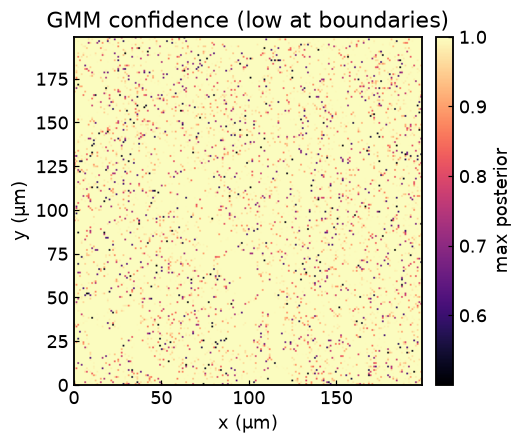

In [7]:
gmm = GaussianMixture(n_components=best_k, covariance_type="full", random_state=0).fit(Xs)
proba = gmm.predict_proba(Xs)           # (n_indents, k) per-phase probabilities
df["gmm"] = gmm.predict(Xs)             # hard label = most likely phase
df["conf"] = proba.max(1)              # confidence = the top probability

gc, ext = mm.map_to_grid(df, "conf")
fig, ax = plt.subplots(figsize=(5.2, 4.2))
mm.plot_map(gc, ext, ax=ax, cmap="magma", label="max posterior",
            title="GMM confidence (low at boundaries)")
fig.tight_layout()
print("median confidence:", round(float(df["conf"].median()), 3))

*🖼 **Figure.** Dark threads trace the phase boundaries, exactly where a single indent overlaps both phases and the model is least sure. This uncertainty map is often more useful than the hard labels.*

## 5 · Density clustering (HDBSCAN)

**HDBSCAN** needs **no `k`**: it finds clusters as dense regions and labels sparse points as
**noise** (`-1`). Useful when phase fractions are very unequal or clusters are odd-shaped.

> 🧠 **HDBSCAN**, a density-based clustering method: dense blobs become clusters, and points in sparse gaps are called *noise* rather than forced into a cluster.

> 🧠 **noise (label −1)**: HDBSCAN's way of saying 'this point doesn't clearly belong to any cluster'. It is a feature, not a failure. Real maps have ambiguous points.

> ✅ **What to look for:** a scatter of **all 40,000** indents coloured by HDBSCAN cluster, with a small fraction (~3%) marked as noise.

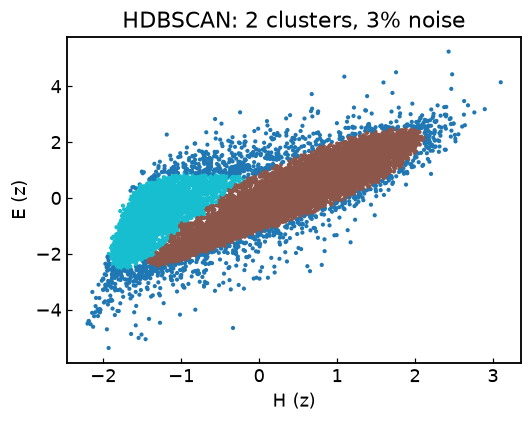

In [8]:
import hdbscan
# HDBSCAN on ALL 40,000 indents — no subsampling (min_cluster_size = smallest phase to keep).
hl = hdbscan.HDBSCAN(min_cluster_size=150, core_dist_n_jobs=1).fit_predict(Xs)  # single-thread: reproducible
n_cl = len(set(hl)) - (1 if -1 in hl else 0)            # count clusters, excluding noise

fig, ax = plt.subplots(figsize=(5, 4))
sc = ax.scatter(Xs[:, 0], Xs[:, 1], c=hl, s=3, cmap="tab10")
ax.set_xlabel("H (z)"); ax.set_ylabel("E (z)")
ax.set_title(f"HDBSCAN: {n_cl} clusters, {(hl == -1).mean() * 100:.0f}% noise"); fig.tight_layout()

## 6 · Do the methods agree?

If independent methods land on the *same* split, the phase segmentation is **robust**, not
an artefact of one algorithm.

> 🧠 **Adjusted Rand Index (ARI)**, a score comparing two groupings: 1.0 = identical, 0 = no better than chance. High ARI between k-means and GMM means they agree on the phases.

> ✅ **What to look for:** a printed ARI around **0.8+** (strong agreement between k-means and GMM).

In [9]:
ari = adjusted_rand_score(df["cluster"], df["gmm"])     # compare the two label sets
print(f"ARI(k-means, GMM) = {ari:.2f}")

ARI(k-means, GMM) = 0.86


### ✅ Self-check
Before moving on, confirm the numbers above make sense. The cell below raises an `AssertionError` if a later change sends a result off the rails.

In [10]:
# Each line fails loudly if a key result drifts out of a sensible range.
# (These also run in CI, so a broken result fails the build.)
assert best_k == 2, "the silhouette should pick k = 2 (two phases)"
assert ari > 0.7, "k-means and GMM should agree strongly"
print("self-check passed ✓ — two robust phases (a third, interface, population is defensible)")

self-check passed ✓ — two robust phases (a third, interface, population is defensible)


## ✅ Recap
- The **silhouette** turns *'how many phases?'* into a defensible number (here k = 2), and **GMM's BIC** gives a second opinion.
- **Two phases are the robust answer**, but a Gaussian mixture will split out a third, **interface / mixed** population — so k = 2 is clean and k = 3 is a defensible finer view.
- **k-means** gives a clean phase map; **GMM** adds calibrated **uncertainty**, most valuable at boundaries.
- **HDBSCAN** needs no `k` and isolates outliers; **ARI** confirms the split is robust.

## 🔧 Try it yourself
Play with it. Re-run the cell after each of these:
1. Force `KMeans(n_clusters=4)` in Section 3 and re-map. Do the extra clusters correspond to real structure, or do they just subdivide a phase?
2. Raise `min_cluster_size` to 400 in the HDBSCAN cell. Does the noise fraction go up or down?
3. Cluster on the AFM grid's PCA curve-scores from notebook 01 instead of `H,E,H/E`. Do you still get two phases?

## 🩹 Common errors & fixes
- **`ModuleNotFoundError: hdbscan`** → install it: `pip install hdbscan` (Windows users may need build tools; conda-forge is easiest).
- **Cluster colours swap between runs** → cluster *ids* are arbitrary labels; the grouping is the same even if colour 0 and 1 trade places.
- **Silhouette cell is slow** → lower `sample_size`, or reduce the range of `k`.

---
**Next:** open **`03_supervised_trees_rf_shap.ipynb`**. Name the phases, then train an interpretable classifier and see *why* it decides.